# МЛ Практика 2: Анализ целевой числойо переменной, базовое моделирование, подбор параметров

### Домашнее задание

In [47]:
!pip install pandas seaborn scikit-learn

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

file_path = 'education_inequality_data.csv'
df = pd.read_csv(file_path)

print(df.head())

   id             school_name     state school_type grade_level  \
0   1      Bowman High School  Michigan     Private        High   
1   2      Foster High School  Michigan     Charter      Middle   
2   3      Henson High School  New York      Public      Middle   
3   4      Weaver High School     Texas     Private  Elementary   
4   5  King Elementary School  Michigan      Public  Elementary   

   funding_per_student_usd  avg_test_score_percent  student_teacher_ratio  \
0                  9575.80                    65.9                   17.5   
1                 16733.10                    87.3                   24.2   
2                 24890.74                    72.8                   27.0   
3                  6857.49                    81.5                   26.2   
4                 16910.73                    44.7                   20.2   

   percent_low_income  percent_minority  internet_access_percent  \
0                30.0              44.0                     74.1  

In [49]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       1000 non-null   int64  
 1   school_name              1000 non-null   object 
 2   state                    1000 non-null   object 
 3   school_type              1000 non-null   object 
 4   grade_level              1000 non-null   object 
 5   funding_per_student_usd  1000 non-null   float64
 6   avg_test_score_percent   1000 non-null   float64
 7   student_teacher_ratio    1000 non-null   float64
 8   percent_low_income       1000 non-null   float64
 9   percent_minority         1000 non-null   float64
 10  internet_access_percent  1000 non-null   float64
 11  dropout_rate_percent     1000 non-null   float64
dtypes: float64(7), int64(1), object(4)
memory usage: 93.9+ KB
None


In [50]:
df_analysis = df.drop(['id', 'school_name'], axis=1)

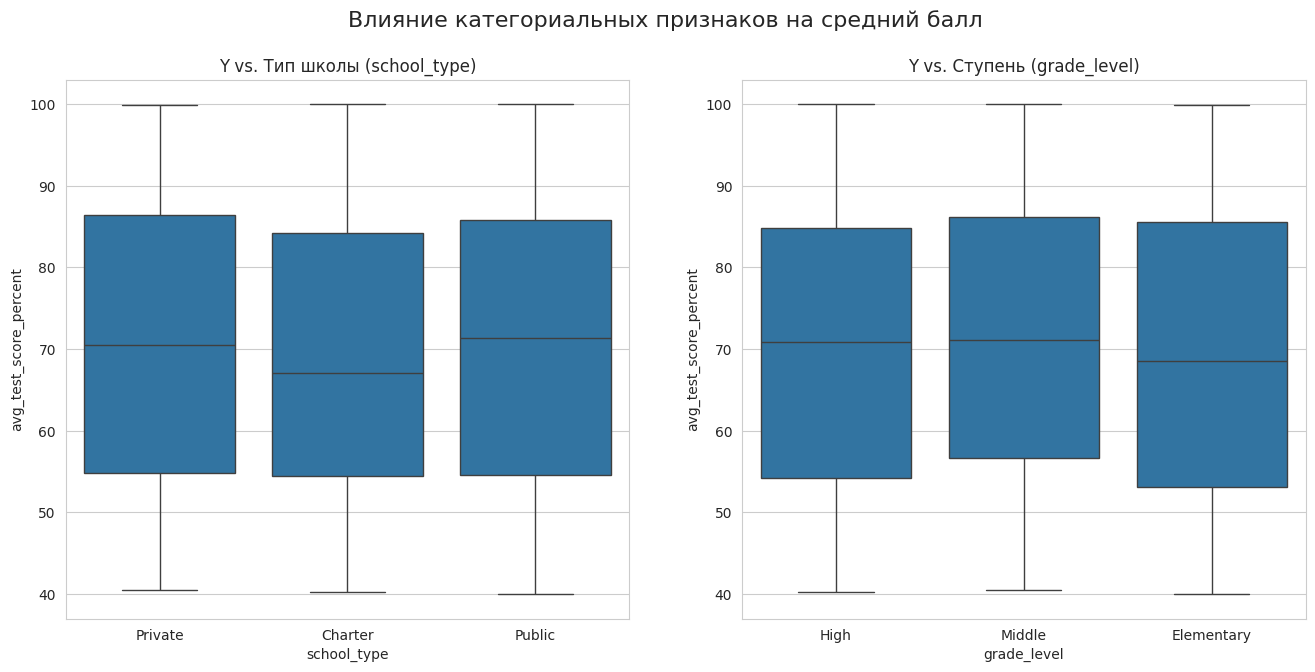

In [51]:
# Категориальные признаки
# state не берем, т.к. там 50+ штатов
categorical_features = ['school_type', 'grade_level']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Влияние категориальных признаков на средний балл', fontsize=16)

sns.boxplot(ax=axes[0], x='school_type', y='avg_test_score_percent', data=df_analysis)
axes[0].set_title('Y vs. Тип школы (school_type)')

sns.boxplot(ax=axes[1], x='grade_level', y='avg_test_score_percent', data=df_analysis)
axes[1].set_title('Y vs. Ступень (grade_level)')

plt.show()

school_type:

Мы видим явное различие. "Коробочка" для Charter (частно-государственные) школы в среднем выше, чем для Private (частные) и Public (государственные).

Это означает, что school_type — очень важный признак для предсказания Y.

grade_level:

Здесь также есть заметная разница. Elementary (начальная) школа в среднем имеет баллы чуть ниже, чем Middle (средняя) и High (старшая).

Разница не такая драматичная, как с типом школы, но она есть. Этот признак тоже полезен.

### Вывод:

Числовые: dropout_rate_percent, percent_low_income и internet_access_percent.

Категориальные: school_type и grade_level

id, school_name: Это идентификаторы, а не признаки.

state: Слишком много категорий. Если мы применим OneHotEncoder, у нас появится 50+ новых колонок.

funding_per_student_usd, student_teacher_ratio, percent_minority: Их корреляция с Y близка к нулю. Они мешают и не помогут обучению.

In [52]:
best_features = [
    # Числовые
    'dropout_rate_percent',
    'percent_low_income',
    'internet_access_percent',
    # Категориальные
    'school_type',
    'grade_level'
]

all_features = [col for col in df_analysis.columns if col not in ['avg_test_score_percent']]

print(f"Все признаки (для 1, 2): {all_features}")
print(f"Лучшие признаки (для 3, 4): {best_features}")

Все признаки (для 1, 2): ['state', 'school_type', 'grade_level', 'funding_per_student_usd', 'student_teacher_ratio', 'percent_low_income', 'percent_minority', 'internet_access_percent', 'dropout_rate_percent']
Лучшие признаки (для 3, 4): ['dropout_rate_percent', 'percent_low_income', 'internet_access_percent', 'school_type', 'grade_level']


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

y = df['avg_test_score_percent']
X = df.drop(['id', 'school_name', 'avg_test_score_percent'], axis=1)

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Числовые признаки: {numerical_features}")
print(f"Категориальные признаки: {categorical_features}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_processed = preprocessor.fit_transform(X)

feature_names = (
    numerical_features +
    preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
)

print(f"Пример первых 5 новых имен признаков: {feature_names[:5]}")
print(f"Пример имен признаков после OHE: {feature_names[-5:]}")

Числовые признаки: ['funding_per_student_usd', 'student_teacher_ratio', 'percent_low_income', 'percent_minority', 'internet_access_percent', 'dropout_rate_percent']
Категориальные признаки: ['state', 'school_type', 'grade_level']
Пример первых 5 новых имен признаков: ['funding_per_student_usd', 'student_teacher_ratio', 'percent_low_income', 'percent_minority', 'internet_access_percent']
Пример имен признаков после OHE: ['school_type_Private', 'school_type_Public', 'grade_level_Elementary', 'grade_level_High', 'grade_level_Middle']


### Модель 1

In [54]:
model_1 = LinearRegression()

model_1.fit(X_processed, y)

y_pred_1 = model_1.predict(X_processed)

print("Модель 1 обучена и предсказания сделаны.")

Модель 1 обучена и предсказания сделаны.


In [55]:
# Функция для расчета MAPE (средняя абсолютная процентная ошибка)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

r2_1 = r2_score(y, y_pred_1)
mae_1 = mean_absolute_error(y, y_pred_1)
mape_1 = mean_absolute_percentage_error(y, y_pred_1)
mse_1 = mean_squared_error(y, y_pred_1)
rmse_1 = np.sqrt(mse_1)

print("Метрики Модели 1 (Все признаки, вся выборка)")
print(f"R² (Коэффициент детерминации): {r2_1:.4f}")
print(f"MAE (Средняя абс. ошибка):     {mae_1:.4f}")
print(f"RMSE (Корень из ср.кв. ошибки): {rmse_1:.4f}")
print(f"MAPE (Средняя абс. % ошибка):  {mape_1:.4f} %")
print(f"MSE (Средняя кв. ошибка):     {mse_1:.4f}")

Метрики Модели 1 (Все признаки, вся выборка)
R² (Коэффициент детерминации): 0.0193
MAE (Средняя абс. ошибка):     15.3128
RMSE (Корень из ср.кв. ошибки): 17.5230
MAPE (Средняя абс. % ошибка):  24.2002 %
MSE (Средняя кв. ошибка):     307.0561


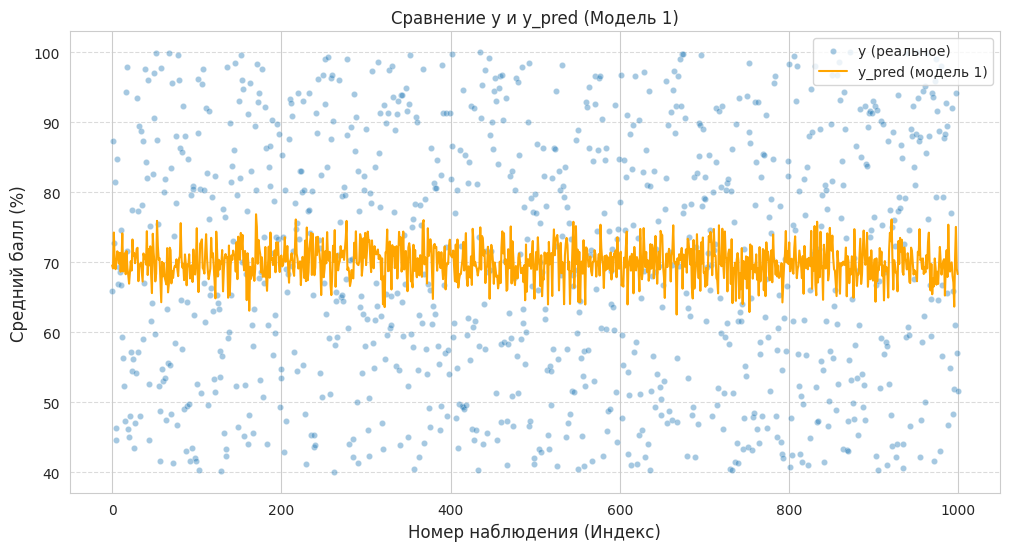

In [56]:
plt.figure(figsize=(12, 6))

# Реальные значения
sns.scatterplot(
    x=range(len(y)),
    y=y,
    label="y (реальное)",
    alpha=0.4,
    s=20
)

# Предсказания
sns.lineplot(
    x=range(len(y_pred_1)),
    y=y_pred_1,
    label="y_pred (модель 1)",
    color="orange",
    linewidth=1.5
)

plt.xlabel("Номер наблюдения (Индекс)", fontsize=12)
plt.ylabel("Средний балл (%)", fontsize=12)
plt.title("Сравнение y и y_pred (Модель 1)")
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Как видно на графике, y (баллы за тесты) сильно колеблется (синие точки). При этом y_pred  — это почти прямая горизонтальная линия (оранжевая).


### Модель 2

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

model_2 = LinearRegression()
model_2.fit(X_train, y_train)

y_pred_train_2 = model_2.predict(X_train)
y_pred_test_2 = model_2.predict(X_test)

In [58]:
# Метрики для обучающей выборки
r2_train_2 = r2_score(y_train, y_pred_train_2)
mae_train_2 = mean_absolute_error(y_train, y_pred_train_2)
rmse_train_2 = np.sqrt(mean_squared_error(y_train, y_pred_train_2))
mape_train_2 = mean_absolute_percentage_error(y_train, y_pred_train_2)

# Метрики для тестовой выборки
r2_test_2 = r2_score(y_test, y_pred_test_2)
mae_test_2 = mean_absolute_error(y_test, y_pred_test_2)
rmse_test_2 = np.sqrt(mean_squared_error(y_test, y_pred_test_2))
mape_test_2 = mean_absolute_percentage_error(y_test, y_pred_test_2)

print("\nМетрики Модели 2 (Обучающая выборка | Train)")
print(f"R² (Train):   {r2_train_2:.4f}")
print(f"MAE (Train):  {mae_train_2:.4f}")
print(f"RMSE (Train): {rmse_train_2:.4f}")
print(f"MAPE (Train): {mape_train_2:.4f} %")

print("\nМетрики Модели 2 (Тестовая выборка | TEST)")
print(f"R² (Test):   {r2_test_2:.4f}")
print(f"MAE (Test):  {mae_test_2:.4f}")
print(f"RMSE (Test): {rmse_test_2:.4f}")
print(f"MAPE (Test): {mape_test_2:.4f} %")


Метрики Модели 2 (Обучающая выборка | Train)
R² (Train):   0.0263
MAE (Train):  15.2460
RMSE (Train): 17.4436
MAPE (Train): 24.1917 %

Метрики Модели 2 (Тестовая выборка | TEST)
R² (Test):   -0.0357
MAE (Test):  15.7313
RMSE (Test): 18.0480
MAPE (Test): 24.0280 %


Модель на всех признаках просто не способна найти общую закономерность.

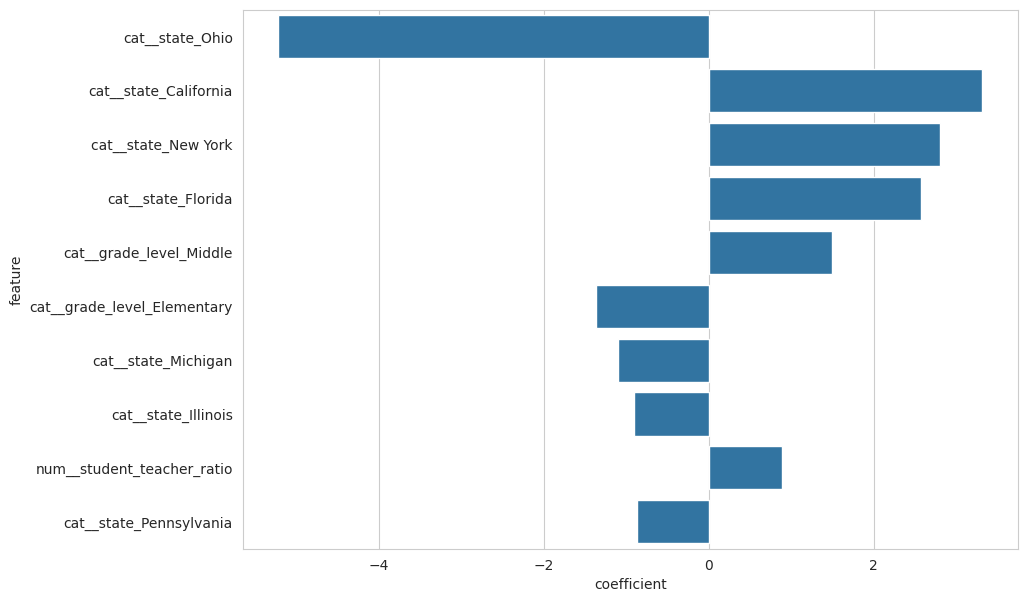

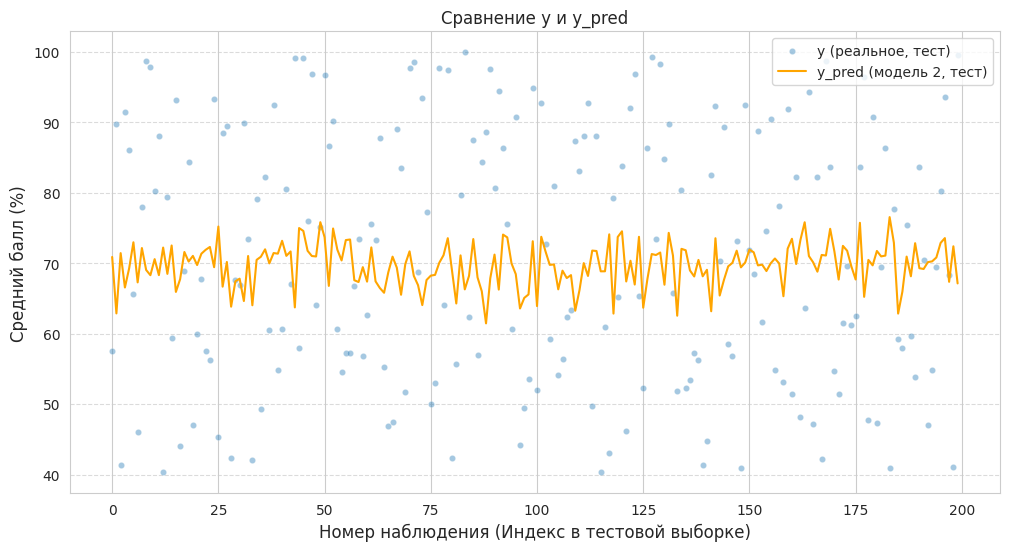

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

try:
    feature_names = preprocessor.get_feature_names_out()
except:
    numerical_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(include='object').columns.tolist()
    feature_names = (
        numerical_features +
        preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
    )

coef_df_2 = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model_2.coef_
})
coef_df_2['abs_coefficient'] = coef_df_2['coefficient'].abs()
coef_df_2 = coef_df_2.sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(
    x='coefficient',
    y='feature',
    data=coef_df_2.head(10)
)
plt.title('')
plt.show()
plt.figure(figsize=(12, 6))

sns.scatterplot(
    x=range(len(y_test)),
    y=y_test,
    label="y (реальное, тест)",
    alpha=0.4,
    s=20
)

sns.lineplot(
    x=range(len(y_pred_test_2)),
    y=y_pred_test_2,
    label="y_pred (модель 2, тест)",
    color="orange",
    linewidth=1.5
)

plt.xlabel("Номер наблюдения (Индекс в тестовой выборке)", fontsize=12)
plt.ylabel("Средний балл (%)", fontsize=12)
plt.title("Сравнение y и y_pred")
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Модель 3

In [60]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    y_true = y_true[non_zero_mask]
    y_pred = y_pred[non_zero_mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


df = pd.read_csv('education_inequality_data.csv')
y = df['avg_test_score_percent']
best_features = [
    'dropout_rate_percent',
    'percent_low_income',
    'internet_access_percent',
    'school_type',
    'grade_level'
]
X_best = df[best_features]

numerical_best = X_best.select_dtypes(include=np.number).columns.tolist()
categorical_best = X_best.select_dtypes(include='object').columns.tolist()

preprocessor_NO_SCALING = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_best),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_best)
    ],
    remainder='passthrough'
)

X_best_processed_no_scaling = preprocessor_NO_SCALING.fit_transform(X_best)

model_3_no_scaling = LinearRegression()
model_3_no_scaling.fit(X_best_processed_no_scaling, y)
y_pred_3_no_scaling = model_3_no_scaling.predict(X_best_processed_no_scaling)

r2_3_ns = r2_score(y, y_pred_3_no_scaling)
mae_3_ns = mean_absolute_error(y, y_pred_3_no_scaling)
rmse_3_ns = np.sqrt(mean_squared_error(y, y_pred_3_no_scaling))
mape_3_ns = mean_absolute_percentage_error(y, y_pred_3_no_scaling)

print("\nМетрики Модели 3")
print(f"R² (Коэффициент детерминации): {r2_3_ns:.4f}")
print(f"MAE (Средняя абс. ошибка):     {mae_3_ns:.4f}")
print(f"RMSE (Корень из ср.кв. ошибки): {rmse_3_ns:.4f}")
print(f"MAPE (Средняя абс. % ошибка):  {mape_3_ns:.4f} %")


Метрики Модели 3
R² (Коэффициент детерминации): 0.0027
MAE (Средняя абс. ошибка):     15.4778
RMSE (Корень из ср.кв. ошибки): 17.6705
MAPE (Средняя абс. % ошибка):  24.5030 %


/tmp/ipython-input-1475043489.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


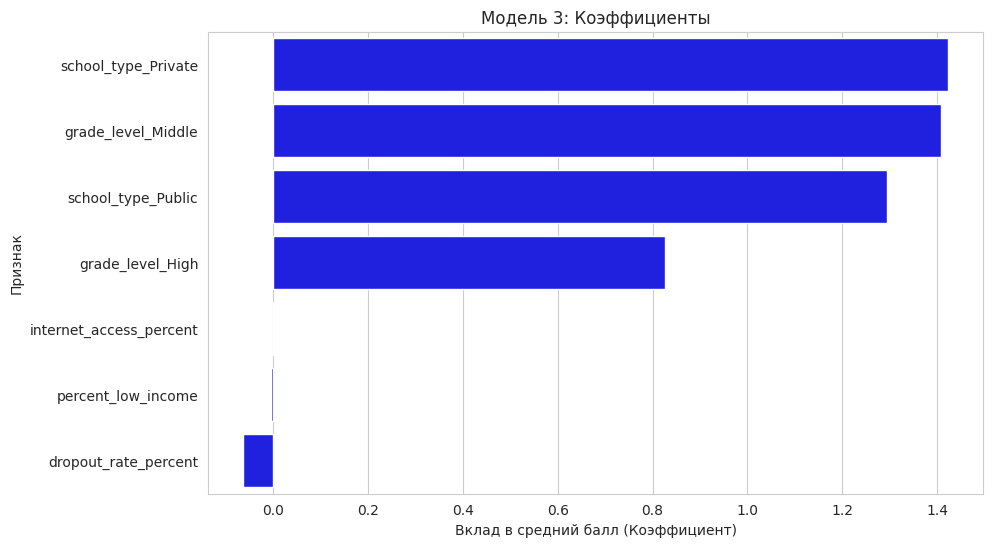

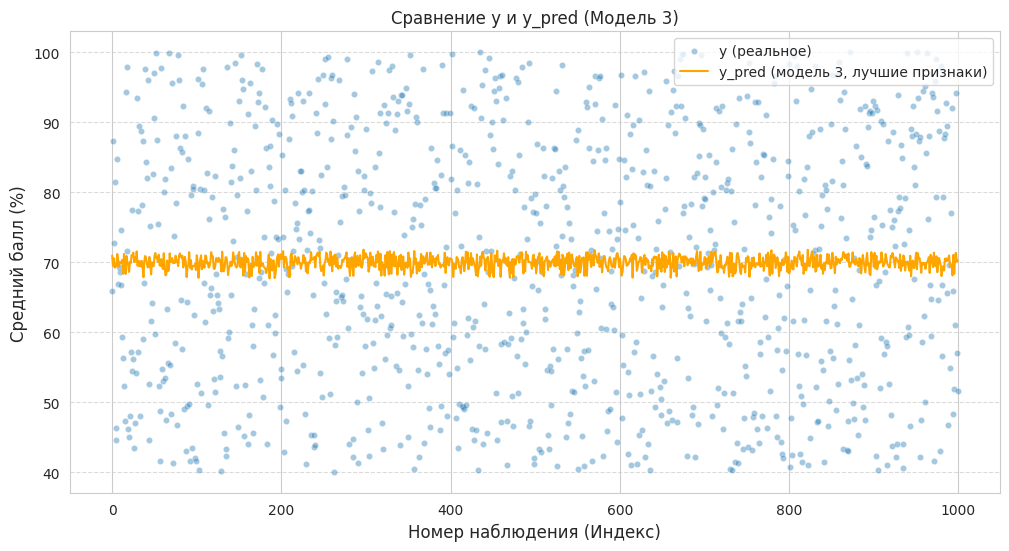

In [61]:
best_feature_names = [
    'dropout_rate_percent', 'percent_low_income', 'internet_access_percent',
    'school_type_Private', 'school_type_Public',
    'grade_level_High', 'grade_level_Middle'
]

coef_df_3 = DataFrame({
    'feature': best_feature_names,
    'coefficient': model_3_no_scaling.coef_
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['blue' if c > 0 else 'blue' for c in coef_df_3['coefficient']]
sns.barplot(
    x='coefficient',
    y='feature',
    data=coef_df_3,
    palette=colors
)
plt.title("Модель 3: Коэффициенты")
plt.xlabel('Вклад в средний балл (Коэффициент)')
plt.ylabel('Признак')
plt.show()

plt.figure(figsize=(12, 6))

# Реальные значения (точки)
sns.scatterplot(
    x=range(len(y)),
    y=y,
    label="y (реальное)",
    alpha=0.4,
    s=20
)

# Предсказания (линия)
sns.lineplot(
    x=range(len(y_pred_3_no_scaling)),
    y=y_pred_3_no_scaling,
    label="y_pred (модель 3, лучшие признаки)",
    color="orange",
    linewidth=1.5
)

plt.xlabel("Номер наблюдения (Индекс)", fontsize=12)
plt.ylabel("Средний балл (%)", fontsize=12)
plt.title("Сравнение y и y_pred (Модель 3)")
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Нет линейной зависимости, линейная регрессия не подходит для этой задачи.

### 4 модель

In [62]:
from sklearn.model_selection import train_test_split

# 1. Разделение X_best_processed_no_scaling
X_train_best_ns, X_test_best_ns, y_train_best, y_test_best = train_test_split(
    X_best_processed_no_scaling,
    y,
    test_size=0.2,
    random_state=42
)

# 2. Обучение Модели 4
model_4 = LinearRegression()
model_4.fit(X_train_best_ns, y_train_best)

# 3. Предсказания
y_pred_train_4 = model_4.predict(X_train_best_ns)
y_pred_test_4 = model_4.predict(X_test_best_ns)

# 4. Расчет метрик
r2_train_4 = r2_score(y_train_best, y_pred_train_4)
mae_train_4 = mean_absolute_error(y_train_best, y_pred_train_4)

r2_test_4 = r2_score(y_test_best, y_pred_test_4)
mae_test_4 = mean_absolute_error(y_test_best, y_pred_test_4)
rmse_test_4 = np.sqrt(mean_squared_error(y_test_best, y_pred_test_4))
mape_test_4 = mean_absolute_percentage_error(y_test_best, y_pred_test_4)

print("\nМетрики Модели 4 (Train/Test)")
print(f"R² (Train):   {r2_train_4:.4f}")
print(f"MAE (Train):  {mae_train_4:.4f}")

print("\nМетрики Модели 4 (Тестовая выборка | TEST)")
print(f"R² (Test):   {r2_test_4:.4f}")
print(f"MAE (Test):  {mae_test_4:.4f}")
print(f"RMSE (Test): {rmse_test_4:.4f}")
print(f"MAPE (Test): {mape_test_4:.4f} %")


Метрики Модели 4 (Train/Test)
R² (Train):   0.0055
MAE (Train):  15.4117

Метрики Модели 4 (Тестовая выборка | TEST)
R² (Test):   -0.0186
MAE (Test):  15.7460
RMSE (Test): 17.8985
MAPE (Test): 24.1583 %


/tmp/ipython-input-2798115061.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


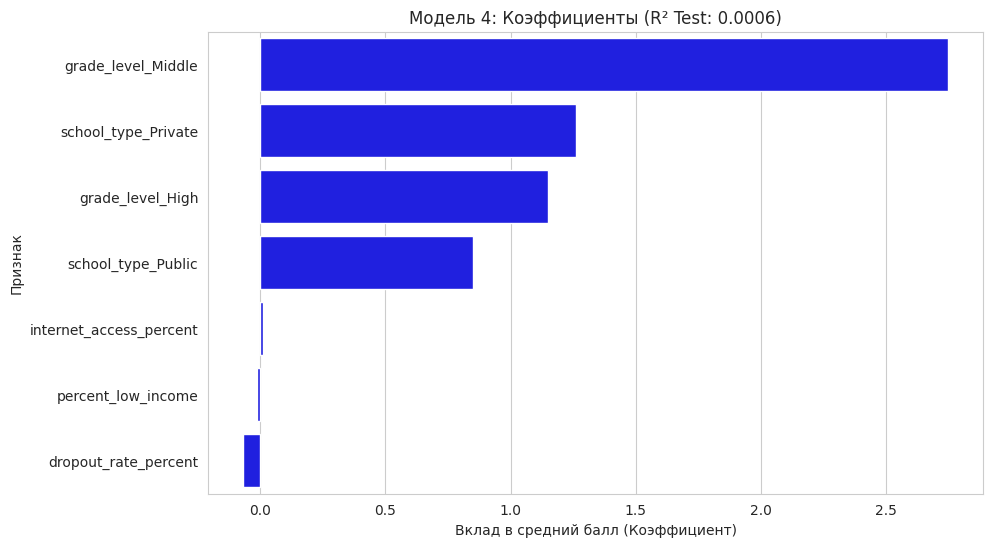

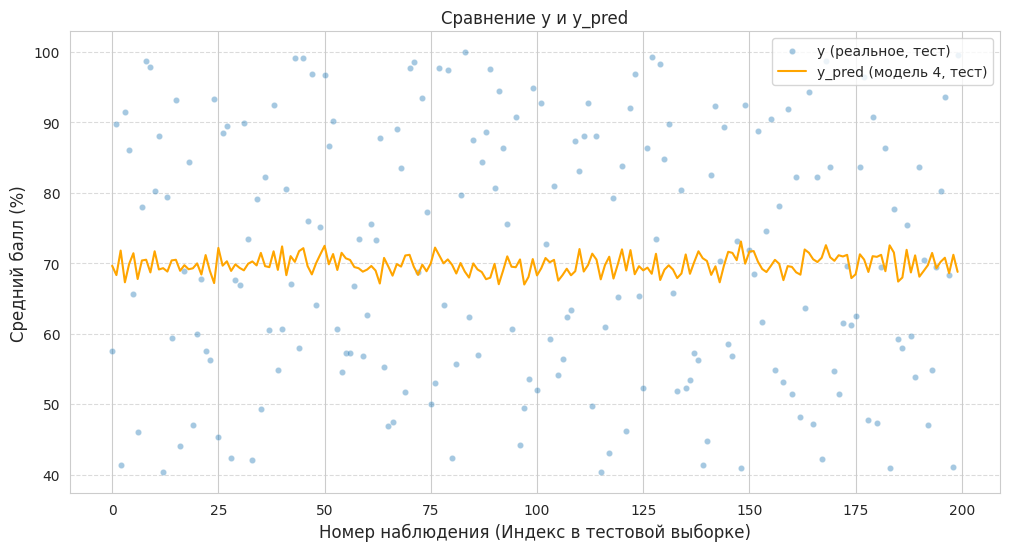

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas import DataFrame

best_feature_names = [
    'dropout_rate_percent', 'percent_low_income', 'internet_access_percent',
    'school_type_Private', 'school_type_Public',
    'grade_level_High', 'grade_level_Middle'
]

coef_df_4 = DataFrame({
    'feature': best_feature_names,
    'coefficient': model_4.coef_
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['blue' if c > 0 else 'blue' for c in coef_df_4['coefficient']]
sns.barplot(
    x='coefficient',
    y='feature',
    data=coef_df_4,
    palette=colors
)

plt.title('Модель 4: Коэффициенты (R² Test: 0.0006)')
plt.xlabel('Вклад в средний балл (Коэффициент)')
plt.ylabel('Признак')
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

r2_test_4 = -0.0186

plt.figure(figsize=(12, 6))

sns.scatterplot(
    x=range(len(y_test_best)),
    y=y_test_best,
    label="y (реальное, тест)",
    alpha=0.4,
    s=20
)

sns.lineplot(
    x=range(len(y_pred_test_4)),
    y=y_pred_test_4,
    label="y_pred (модель 4, тест)",
    color="orange",
    linewidth=1.5
)

plt.xlabel("Номер наблюдения (Индекс в тестовой выборке)", fontsize=12)
plt.ylabel("Средний балл (%)", fontsize=12)
plt.title(f"Сравнение y и y_pred")
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

1. Коэффициент детерминации
R для всех моделей, включая Модель 4 на тестовой выборке отрицателен. R = -0.0186 означает, что модель не объясняет абсолютно ничего и даже хуже, чем простое предсказание среднего значения Y для каждой школы. Ни одна из четырех построенных моделей линейной регрессии не смогла найти значимой линейной зависимости в данных.
2. Оценка MAE (Средней Абсолютной Ошибки): MAE на тестовой выборке составляет 15.74. В среднем, модель ошибается на 15.74 процентных пункта при предсказании среднего балла. Если реальный балл школы 75, модель может предсказать 59 или 90. Это чрезмерно высокая ошибка, делающая модель бесполезной для практического применения.
